# 位置编码变种大全（Positional Encoding Variants）

> **课程**：minLLM —— 从零实现小型 LLM ｜ 第三篇：位置编码
>
> 上一篇（② 多头注意力）里，注意力对**内容**做加权求和；这一篇解决另一个问题：**让模型知道"谁在哪个位置"**。

## 为什么需要位置编码？

自注意力本身是**置换等变（permutation equivariant）**的：

- $Q=XW_Q,\;K=XW_K,\;V=XW_V$，注意力分数 $QK^{\top}/\sqrt{d}$ 只由**内容**决定，与 token 在序列中的先后顺序无关；
- 把输入序列 $[x_1,x_2,\dots,x_T]$ 任意打乱成 $[x_{\pi(1)},x_{\pi(2)},\dots]$，输出也以同样的顺序打乱——模型**分不出「我打你」和「你打我」**；
- 所以必须把"位置"作为**额外信号**注入输入（或注意力分数），让每个位置拥有不同的"身份"。

本 notebook 系统对比 **5 种主流位置编码**：正弦（Sinusoidal）、可学习（Learned）、RoPE、ALiBi、T5 相对偏置，
每种都配齐「手搓 NumPy + torch 参考 + 数值对比 + 可视化」四件套。

**统一超参**：$d_{model}=16$，序列长度 $T=20$，最大长度 $MAX\_LEN=50$；
随机种子固定（`np.random.seed(0)` / `torch.manual_seed(0)`），整个 notebook 可完全复现。

## 五种变种总览（先看结论，再逐个拆解）

| 变种 | 核心原理 | 代表模型 | 一句话优点 | 一句话缺点 |
|---|---|---|---|---|
| ① 正弦 Sinusoidal | 不同频率的 sin/cos 给每个位置生成固定向量 | Transformer (2017)、GPT-1/2 | 无需训练、可外推 | 表达固定，无法随任务自适应 |
| ② 可学习 Learned | `nn.Embedding(max_len, d)` 查表，随训练更新 | BERT、GPT-2/3 | 灵活、数据驱动 | 需训练；`max_len` 固定，不能外推 |
| ③ RoPE 旋转编码 | 把 Q/K 按位置旋转 $\theta=pos\cdot 10000^{-2i/d}$，点积自动含相对位置 | LLaMA、MiniMind、PaLM | 显式相对位置、外推好、decoder-only 高效 | 实现稍复杂 |
| ④ ALiBi 线性偏置 | 注意力分数直接减 $m\cdot|i-j|$ | BLOOM、MPT | 零参数、无需训练、外推极好 | 线性惩罚表达能力有限 |
| ⑤ T5 相对偏置 | 相对距离 bucket 化后查可学习 bias 表 | T5 | 相对位置 + 可学习、鲁棒 | 需维护 bucket 映射，跨长度需重映射 |

**四种"注入位置"的路线**（注意区分）：

1. **加在输入上**（正弦、可学习）：$x_{pos} \leftarrow x_{pos}+PE[pos]$，位置信息靠后续的点积间接起作用；
2. **旋转 Q/K**（RoPE）：$q \leftarrow R(pos)\,q$，让点积**天然**携带相对位置；
3. **改注意力分数**（ALiBi、T5）：$\text{score} \leftarrow \text{score} + B[i,j]$，直接惩罚/偏置远距离。

In [1]:
# 0. 导入库与全局配置：手搓 NumPy + torch 参考 + 数值对比 + 可视化 四件套
import matplotlib                        # 画图库（先 import 才能设后端）
matplotlib.use('Agg')                    # 无显示环境：非交互后端，图渲染进 notebook
import matplotlib.pyplot as plt          # pyplot 接口
import numpy as np                       # 手搓实现的计算库
import torch                             # torch 参考
import torch.nn as nn                    # nn.Embedding 等现成模块
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False   # 让负号正常显示

# ---- 统一超参 ----
D_MODEL = 16      # 模型维度（MiniMind 通常 512/768，这里用 16 便于可视化）
T = 20            # 序列长度（token 个数）
MAX_LEN = 50      # 位置编码允许的最大长度（可学习编码的容量上限）
BASE = 10000.0    # 频率底数（正弦与 RoPE 共用；MiniMind 用 1e6，规律相同）

# ---- 固定随机种子：保证每次运行结果一致，方便讲课复现 ----
np.random.seed(0)      # NumPy 随机种子
torch.manual_seed(0)   # PyTorch 随机种子

# ---- 统一对比输出函数：所有"手搓 vs torch"都用它打印结论 ----
def report(name, max_err):
    """统一输出对比结论（✓ PASS / ✗ FAIL）"""
    ok = '✓ PASS' if max_err < 1e-5 else '✗ FAIL'
    print(f'[{name}] 最大误差 = {max_err:.3e}  {ok}')

print(f'd_model={D_MODEL}, T={T}, max_len={MAX_LEN}')

d_model=16, T=20, max_len=50


## 变种一：正弦位置编码（Sinusoidal Positional Encoding）

出自 Attention Is All You Need（Vaswani et al., 2017）。对位置 $pos$、维度索引 $i$：

$$
PE(pos, 2i)   = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right), \qquad
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

**直觉拆解**：

- **维度分工**：偶数维放 $\sin$、奇数维放 $\cos$，相邻两维 $(2i, 2i+1)$ 构成一对，等价于复平面上的 $e^{i\theta}$；
- **频率阶梯**：$10000^{-2i/d}$ 随 $i$ 增大而快速减小 → **低维慢变（粗粒度）、高维快变（细粒度）**，类似傅里叶展开：用不同频率的组合唯一地"编码"每个位置；
- **为什么能表达相对位置**：对固定维度对，两个位置向量的点积只与**距离** $k$ 有关（积化和差），模型据此能推断"谁离谁多远"，这是后续所有"相对位置"思想的原点。

下面的代码手搓出矩阵后，直接可视化：(a) 热力图看整体结构；(b) 曲线看不同维度的频率差异。

In [2]:
# 变种一：正弦位置编码 —— 手搓 NumPy
def sinusoidal_encoding_numpy(max_len, d_model):
    """正弦位置编码矩阵 (max_len, d_model)：PE(pos,2i)=sin, PE(pos,2i+1)=cos"""
    pos = np.arange(max_len)[:, None].astype(np.float32)   # 位置列向量 (max_len,1)
    i = np.arange(d_model // 2).astype(np.float32)         # 维度对索引 (d/2,)
    inv_freq = 1.0 / np.power(BASE, 2.0 * i / d_model)     # 角频率 10000^(-2i/d)：i 越大变化越慢
    angles = pos * inv_freq                                # 角度矩阵 (max_len,d/2)
    pe = np.empty((max_len, d_model), dtype=np.float32)    # 预分配输出
    pe[:, 0::2] = np.sin(angles)   # 偶数维 ← sin
    pe[:, 1::2] = np.cos(angles)   # 奇数维 ← cos
    return pe

pe_np = sinusoidal_encoding_numpy(MAX_LEN, D_MODEL)
print('正弦编码形状:', pe_np.shape, '| 位置0编码(偶维0/奇维1):', np.round(pe_np[0, :8], 3))

正弦编码形状: (50, 16) | 位置0编码(偶维0/奇维1): [0. 1. 0. 1. 0. 1. 0. 1.]


In [3]:
# 变种一：torch 参考实现（同一公式，逐元素对应）
def sinusoidal_encoding_torch(max_len, d_model):
    """与 numpy 版本等价的 torch 实现"""
    pos = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)   # 位置列向量 (max_len,1)
    i = torch.arange(d_model // 2, dtype=torch.float32)             # 维度对索引 (d/2,)
    inv_freq = 1.0 / torch.pow(BASE, 2.0 * i / d_model)             # 角频率
    angles = pos * inv_freq                                         # 角度矩阵
    pe = torch.empty(max_len, d_model, dtype=torch.float32)
    pe[:, 0::2] = torch.sin(angles)   # 偶数列 sin
    pe[:, 1::2] = torch.cos(angles)   # 奇数列 cos
    return pe

pe_pt = sinusoidal_encoding_torch(MAX_LEN, D_MODEL)
print('torch 编码形状:', tuple(pe_pt.shape))

torch 编码形状: (50, 16)


In [4]:
# 变种一：数值对比（逐元素相减取最大绝对值，两侧应是同一份数据）
err_v1 = float(np.abs(pe_np - pe_pt.numpy()).max())
report('正弦位置编码 numpy vs torch', err_v1)

[正弦位置编码 numpy vs torch] 最大误差 = 5.960e-08  ✓ PASS


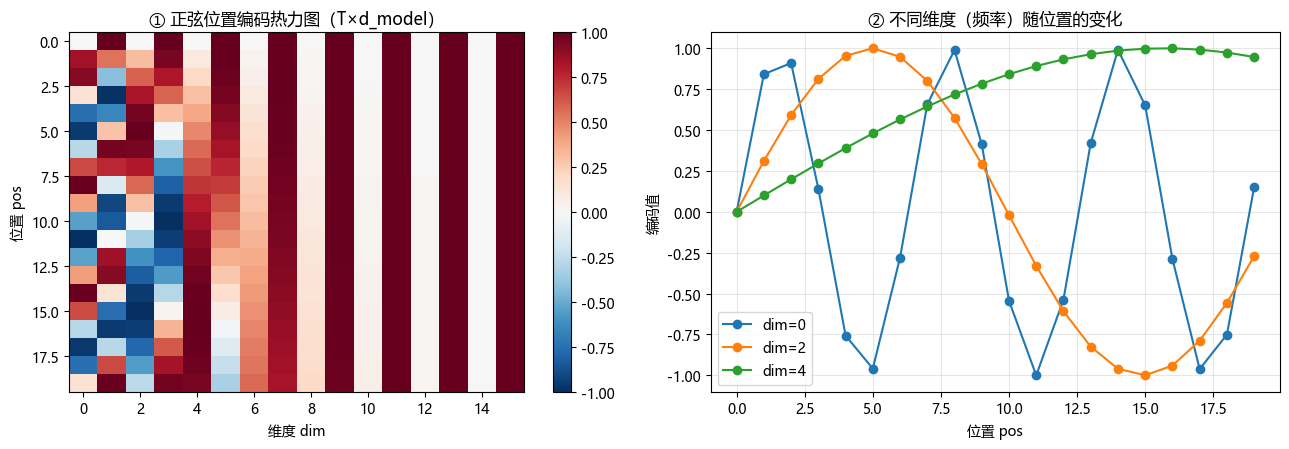

In [5]:
# 变种一：可视化 —— 热力图 + 频率曲线
# 关键：切到 inline 后端，plt.show() 的图才会被捕获进 notebook（无显示环境同样适用）
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))   # 左：热力图；右：曲线
im = axes[0].imshow(pe_np[:T], aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('① 正弦位置编码热力图（T×d_model）')
axes[0].set_xlabel('维度 dim'); axes[0].set_ylabel('位置 pos')
fig.colorbar(im, ax=axes[0])                     # 色条
for dim in [0, 2, 4]:                            # 不同频率维度随位置的变化
    axes[1].plot(pe_np[:T, dim], marker='o', label=f'dim={dim}')
axes[1].set_title('② 不同维度（频率）随位置的变化')
axes[1].set_xlabel('位置 pos'); axes[1].set_ylabel('编码值')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()   # 关键：show() 才会把图渲染进 notebook

## 变种二：可学习位置编码（Learnable Positional Encoding）

BERT、GPT-2/3 等采用的做法：直接维护一个**可学习的位置查表矩阵**：

$$
PE \in \mathbb{R}^{max\_len \times d_{model}}, \qquad h_{pos} = x_{pos} + PE[pos]
$$

- 本质就是 `nn.Embedding(max_len, d_model)`：每个位置对应**一行自由参数**，随机初始化后随整个模型一起反向传播更新；
- **优点**：完全数据驱动，模型自己决定"什么样的位置信号最有用"；
- **缺点**：① 参数量 $max\_len \times d$ 随长度线性增长；② 只能在训练见过的长度内工作，序列更长时直接越界（**外推差**）——这正是后来 RoPE / ALiBi 兴起的原因之一。

由于它是"查表 + 学习"，手搓版本几乎没有公式：我们直接演示
**初始化 → 定义损失 → 手算梯度 → SGD 更新一次**，并用 `nn.Embedding` + autograd 做逐值对照，
重点看清"损失只依赖哪个位置，梯度就只落在哪一行"。

In [6]:
# 变种二：可学习位置编码 —— 手搓（初始化 + 一次 SGD 更新）
np.random.seed(0)                                    # 固定种子，便于与 torch 对齐
P = np.random.randn(MAX_LEN, D_MODEL).astype(np.float32) * 0.02   # 随机初始化可学习矩阵
print('初始 P 形状:', P.shape, '| 位置3前4值:', np.round(P[3, :4], 4))

POS_USED = 3                                # 本次"用到"的位置下标（其余行梯度为 0）
target = np.ones(D_MODEL, dtype=np.float32) # 目标向量（教学演示随意定义）
lr = 0.1                                    # 学习率
# 损失 L = ||P[3]-target||²，手算梯度 dL/dP[3] = 2*(P[3]-target)
loss = float(np.sum((P[POS_USED] - target) ** 2))
grad = 2.0 * (P[POS_USED] - target)         # 只有这一行有梯度
print(f'更新前损失: {loss:.4f} | 梯度前4值:', np.round(grad[:4], 4))
# SGD 更新：P_new = P - lr·grad（只有 POS_USED 行变化）
P_new = P.copy()
P_new[POS_USED] -= lr * grad
print('更新后位置3前4值:', np.round(P_new[POS_USED, :4], 4))

初始 P 形状: (50, 16) | 位置3前4值: [-0.0323 -0.0043 -0.0179  0.0077]
更新前损失: 16.3172 | 梯度前4值: [-2.0646 -2.0085 -2.0358 -1.9845]
更新后位置3前4值: [0.1742 0.1966 0.1857 0.2062]


In [7]:
# 变种二：torch 参考 —— nn.Embedding + autograd 自动求梯度
emb = nn.Embedding(MAX_LEN, D_MODEL)        # 可学习位置表
with torch.no_grad():
    emb.weight.copy_(torch.tensor(P))       # 初始权重拷成与 numpy 完全一致
x_row = emb(torch.tensor([POS_USED]))       # 取位置 POS_USED 的编码行 (1,d)
target_t = torch.ones(1, D_MODEL)           # 目标向量
loss_t = torch.sum((x_row - target_t) ** 2) # 与 numpy 相同的损失
loss_t.backward()                           # autograd 自动求梯度
grad_t = emb.weight.grad[POS_USED].numpy()  # 被使用那行的梯度
report('可学习编码 手算梯度 vs torch 梯度',
       float(np.abs(grad - grad_t).max()))
with torch.no_grad():
    emb.weight[POS_USED] -= lr * emb.weight.grad[POS_USED]   # 同一 lr 更新
P_torch = emb.weight.detach().numpy()
report('可学习编码 更新后矩阵 numpy vs torch',
       float(np.abs(P_new - P_torch).max()))

[可学习编码 手算梯度 vs torch 梯度] 最大误差 = 0.000e+00  ✓ PASS
[可学习编码 更新后矩阵 numpy vs torch] 最大误差 = 0.000e+00  ✓ PASS


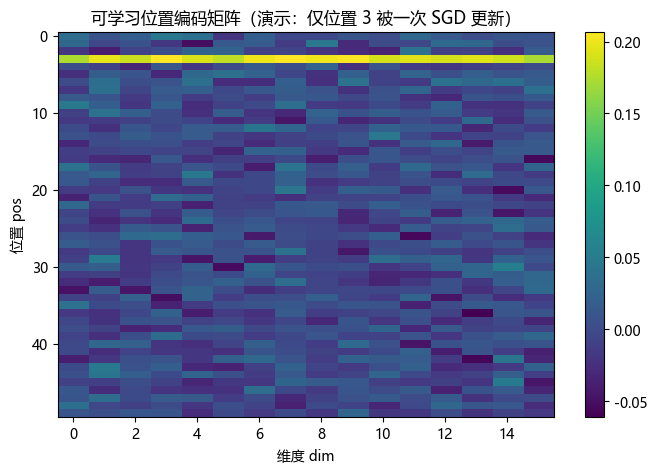

In [8]:
# 变种二：可视化 —— "学习到"的位置矩阵热力图
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(P_torch, aspect='auto', cmap='viridis')
ax.set_title('可学习位置编码矩阵（演示：仅位置 3 被一次 SGD 更新）')
ax.set_xlabel('维度 dim'); ax.set_ylabel('位置 pos')
fig.colorbar(im, ax=ax)
plt.show()

## 变种三：RoPE 旋转位置编码（Rotary Position Embedding）★ 教学重点

MiniMind / LLaMA / PaLM 采用的位置编码。核心思想：**把位置信息"旋转"进 Q 和 K，让点积自动携带相对位置**。

### 二维旋转

把相邻的两个维度 $(x_1, x_2)$ 看成平面上的一个点，按角度 $\theta$ 旋转：

$$
\begin{pmatrix} x_1' \\ x_2' \end{pmatrix}
=
\begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}
\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}
$$

对位置 $pos$、第 $i$ 个维度对（$i=0,\dots,d/2-1$），旋转角：

$$
\theta_i(pos) = pos \cdot 10000^{-2i/d_{model}}
$$

### 复数视角

旋转在复数域就是**乘一个单位复数**：$(x_1 + i x_2) \mapsto e^{i\theta}(x_1 + i x_2)$，其中 $e^{i\theta}=\cos\theta+i\sin\theta$。这就是实现里常用"复数乘法"的原因（见代码：`freqs_cis = cos + i·sin`）。

### 频率矩阵推导

把所有维度对的频率写成向量：$\text{inv\_freq} = \left[10000^{0},\; 10000^{-2/d},\; \dots,\; 10000^{-2(d/2-1)/d}\right]$；
角度矩阵是位置与外积：$\Theta = pos \otimes \text{inv\_freq}$，形状 $(max\_len, d/2)$——
每个位置得到 $d/2$ 个角度，分别旋转 $d/2$ 个二维子空间（与正弦编码共用同一套"频率阶梯"）。

### 为什么旋转能表达相对位置？—— 点积的旋转不变性

$$
\langle R_m q,\; R_n k \rangle
= q^{\top} R_m^{\top} R_n k
= q^{\top} R_{n-m} k
= \langle q,\; R_{n-m} k \rangle
$$

推导：旋转矩阵是正交的（$R^{\top}=R^{-1}$），且旋转的复合等于角度相加 → $R_m^{\top}R_n = R_{-m}R_n = R_{n-m}$。
于是"两个都被旋转过的向量做点积"等价于"第一个不转、第二个只转**相对角度** $n-m$"——
**注意力分数只依赖相对距离 $|n-m|$**，这正是语言"越近越相关"需要的归纳偏置，也是 RoPE 外推性好的根源。

下面用三种可视化看透它：① 复平面上向量随位置旋转；② 相邻位置的夹角恒定；③ 旋转后 Q/K 的注意力呈带状结构。

In [9]:
# 变种三：RoPE —— 手搓 NumPy（复数乘法路线）
def precompute_freqs_cis_numpy(max_len, d_model, base=BASE):
    """预计算旋转角并转成复数 e^{iθ}，返回 (max_len, d/2) 复数数组（cis=cos+i·sin）"""
    i = np.arange(d_model // 2).astype(np.float32)        # 维度对索引 (d/2,)
    inv_freq = 1.0 / np.power(base, 2.0 * i / d_model)    # 各维度对角频率（低索引高频率）
    pos = np.arange(max_len).astype(np.float32)           # 位置向量
    angles = np.outer(pos, inv_freq)                      # 角度矩阵 = 位置⊗频率 (max_len,d/2)
    freqs_cis = (np.cos(angles) + 1j * np.sin(angles)).astype(np.complex64)  # e^{iθ}
    return freqs_cis

def apply_rotary_emb_numpy(x, freqs_cis):
    """把 x(T,d) 每对相邻维度 (x1,x2) 看作复数 x1+i·x2，乘对应位置 e^{iθ} 完成旋转，再拆回实数"""
    T = x.shape[0]
    x_ = x.reshape(T, -1, 2)                              # (T, d/2, 2)：最后一维 [x1,x2]
    x_c = (x_[:, :, 0] + 1j * x_[:, :, 1]).astype(np.complex64)  # 转复数 (T,d/2)
    x_r = x_c * freqs_cis                                 # 复数乘法 = 旋转
    out = np.stack([x_r.real, x_r.imag], axis=-1)         # 实部第1列、虚部第2列
    return out.reshape(T, -1)                             # 还原 (T,d)

# 旋转矩阵法等价写法（与复数乘法二选一即可）：[x1';x2']=[cos -sin; sin cos]·[x1;x2]
# def apply_rotary_emb_matrix(x, freqs):
#     T = x.shape[0]; cos_, sin_ = freqs.real, freqs.imag
#     x2 = x.reshape(T, -1, 2); x1, y1 = x2[..., 0], x2[..., 1]
#     return np.stack([x1*cos_-y1*sin_, x1*sin_+y1*cos_], axis=-1).reshape(T, -1)

# 演示：随机 token 向量，对整条序列做旋转
np.random.seed(0)
x = np.random.randn(T, D_MODEL).astype(np.float32)        # 20 个 token 的原始向量
freqs_cis = precompute_freqs_cis_numpy(T, D_MODEL)
x_rot = apply_rotary_emb_numpy(x, freqs_cis)
print('freqs_cis:', freqs_cis.shape, '| 旋转后 x_rot:', x_rot.shape)

freqs_cis: (20, 8) | 旋转后 x_rot: (20, 16)


In [10]:
# 变种三：torch 参考实现（同一公式；torch 原生支持复数张量）
def precompute_freqs_cis_torch(max_len, d_model, base=BASE):
    """torch 版本：与 numpy 逐元素等价"""
    i = torch.arange(d_model // 2, dtype=torch.float32)
    inv_freq = 1.0 / torch.pow(base, 2.0 * i / d_model)
    pos = torch.arange(max_len, dtype=torch.float32)
    angles = torch.outer(pos, inv_freq)                              # (max_len,d/2)
    freqs_cis = torch.complex(torch.cos(angles), torch.sin(angles))  # e^{iθ}
    return freqs_cis

def apply_rotary_emb_torch(x, freqs_cis):
    """torch 版本：拆复 → 乘复 → 还原"""
    T = x.shape[0]
    x_ = x.reshape(T, -1, 2)
    x_c = torch.complex(x_[:, :, 0], x_[:, :, 1])                    # x1 + i·x2
    x_r = x_c * freqs_cis                                            # 复数乘法 = 旋转
    out = torch.stack([x_r.real, x_r.imag], dim=-1)
    return out.reshape(T, -1)

x_t = torch.tensor(x)   # 与 numpy 同一份输入
freqs_cis_t = precompute_freqs_cis_torch(T, D_MODEL)
x_rot_t = apply_rotary_emb_torch(x_t, freqs_cis_t)

In [11]:
# 变种三：数值对比（频率表与旋转结果两侧逐一核对）
report('RoPE 频率表 numpy vs torch', float(np.abs(freqs_cis - freqs_cis_t.numpy()).max()))
report('RoPE 旋转结果 numpy vs torch', float(np.abs(x_rot - x_rot_t.numpy()).max()))

[RoPE 频率表 numpy vs torch] 最大误差 = 8.429e-08  ✓ PASS
[RoPE 旋转结果 numpy vs torch] 最大误差 = 2.384e-07  ✓ PASS


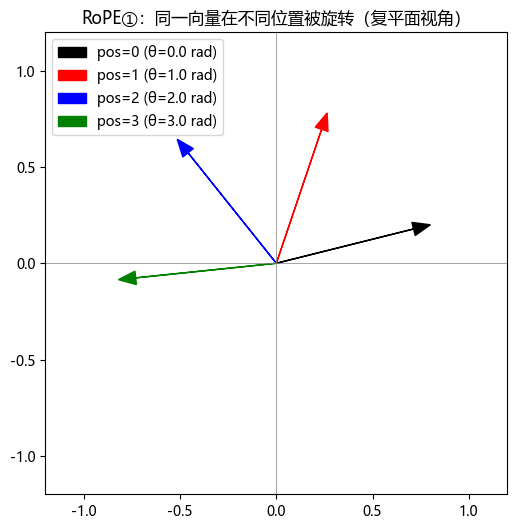

In [12]:
# 变种三：可视化① —— 2D 复平面：同一向量随位置旋转（箭头图）
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.2, 6))
v = np.array([0.8, 0.2])                       # 基准二维向量（第 0 个维度对）
for p, c in zip([0, 1, 2, 3], ['black', 'red', 'blue', 'green']):
    theta = float(p) * 1.0                     # i=0 时频率=1 → 角度=位置数（弧度）
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])   # 2D 旋转矩阵
    r = R @ v                                  # 旋转后的向量
    ax.arrow(0, 0, r[0], r[1], head_width=0.07, head_length=0.09,
             fc=c, ec=c, length_includes_head=True, label=f'pos={p} (θ={theta:.1f} rad)')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_aspect('equal')
ax.set_title('RoPE①：同一向量在不同位置被旋转（复平面视角）')
ax.legend(loc='upper left')
plt.show()

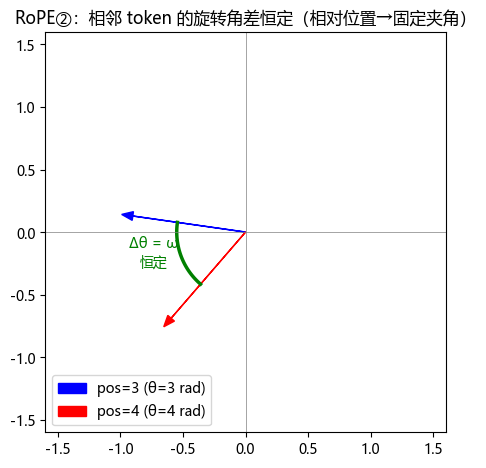

In [13]:
# 变种三：可视化② —— 相邻位置的旋转夹角恒定（相对位置 → 固定夹角）
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.2, 5.2))
omega = 1.0                              # 第 0 个维度对：inv_freq=1
p3, p4 = 3.0, 4.0                        # 相邻两个位置
for p, cn, lab in [(p3, 'blue', f'pos=3 (θ={p3:.0f} rad)'),
                   (p4, 'red',  f'pos=4 (θ={p4:.0f} rad)')]:
    a = p * omega                        # 该位置对应的旋转角
    ax.arrow(0, 0, np.cos(a), np.sin(a), head_width=0.07, head_length=0.09,
             fc=cn, ec=cn, length_includes_head=True, label=lab)
th = np.linspace(p3 * omega, p4 * omega, 60)      # 圆弧标出相邻夹角 Δθ = ω
ax.plot(0.55 * np.cos(th), 0.55 * np.sin(th), color='green', lw=2.5)
ax.text(0.78 * np.cos(3.5), 0.78 * np.sin(3.5), 'Δθ = ω\n恒定', color='green', ha='center')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6); ax.set_aspect('equal')
ax.set_title('RoPE②：相邻 token 的旋转角差恒定（相对位置→固定夹角）')
ax.legend(loc='lower left')
plt.show()

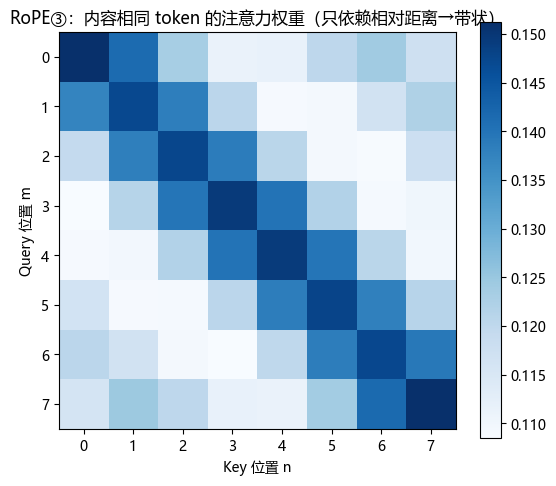

In [14]:
# 变种三：可视化③ —— 旋转后 Q/K 的相对位置注意力（带状结构）
import matplotlib.pyplot as plt
np.random.seed(1)    # 内容几乎相同的 8 个 token：消除内容差异，只保留位置信号
x_same = (0.5 + 0.01 * np.random.randn(8, D_MODEL)).astype(np.float32)
freqs8 = precompute_freqs_cis_numpy(8, D_MODEL)
x_rot8 = apply_rotary_emb_numpy(x_same, freqs8)     # 旋转后的 Q、K（演示取 Q=K）
scores8 = (x_rot8 @ x_rot8.T) / np.sqrt(D_MODEL)    # 缩放点积分数
e = np.exp(scores8 - scores8.max(axis=1, keepdims=True))   # 数值稳定 softmax
attn8 = e / e.sum(axis=1, keepdims=True)            # 注意力权重（每行和为 1）
fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(attn8, cmap='Blues')
ax.set_title('RoPE③：内容相同 token 的注意力权重（只依赖相对距离→带状）')
ax.set_xlabel('Key 位置 n'); ax.set_ylabel('Query 位置 m')
fig.colorbar(im, ax=ax)
plt.show()

## 变种四：ALiBi 线性偏置（Attention with Linear Biases）

BLOOM / MPT 采用。改动极小：把注意力分数直接加上**只与距离有关的线性惩罚**：

$$
\text{score}(i, j) = \frac{q_i^{\top} k_j}{\sqrt{d}} \;-\; m \cdot |i - j|
$$

- $m$ 是**头相关**的斜率：多头时各头用递减序列 $\frac12,\frac14,\frac18,\dots$（BLOOM 采用），单头演示取 $m=0.1$；
- **零参数、无需训练**：$m$ 直接给定，不参与反向传播；
- 效果：越远的 token 被压得越狠（近处注意力高、远处低），而且**不限制输入长度**——任意长度都能算 $|i-j|$，外推能力极强、实现极简。

我们手搓出偏置矩阵 $B[i,j] = -m|i-j|$，与 torch 对照后，用**热力图 + 3D 曲面**看清楚它的"V 形谷"。

In [15]:
# 变种四：ALiBi —— 手搓线性偏置矩阵
def alibi_bias_numpy(T, m=0.1):
    """生成 ALiBi 偏置 B[i,j] = -m·|i-j|，形状 (T,T)，直接加到注意力分数上（零参数）"""
    i = np.arange(T)[:, None]     # (T,1) query 下标
    j = np.arange(T)[None, :]     # (1,T) key 下标
    dist = np.abs(i - j)          # 广播得到距离矩阵 |i-j|
    return (-m * dist).astype(np.float32)

np.random.seed(0)
scores0 = np.random.randn(T, T).astype(np.float32)   # 模拟 QK^T/√d
bias_alibi = alibi_bias_numpy(T, m=0.1)
scores_alibi = scores0 + bias_alibi                  # 叠加偏置
print('bias[0,0] =', bias_alibi[0, 0], '| bias[0,10] =', bias_alibi[0, 10])

bias[0,0] = -0.0 | bias[0,10] = -1.0


In [16]:
# 变种四：torch 参考 + 数值对比（同一公式，同一份分数）
i = torch.arange(T).unsqueeze(1); j = torch.arange(T).unsqueeze(0)
bias_t = (-0.1 * torch.abs(i - j)).float()           # B[i,j] = -m|i-j|
scores_alibi_t = torch.tensor(scores0) + bias_t
report('ALiBi 偏置矩阵 numpy vs torch', float(np.abs(bias_alibi - bias_t.numpy()).max()))
report('ALiBi 叠加后分数 numpy vs torch', float(np.abs(scores_alibi - scores_alibi_t.numpy()).max()))

[ALiBi 偏置矩阵 numpy vs torch] 最大误差 = 1.192e-07  ✓ PASS
[ALiBi 叠加后分数 numpy vs torch] 最大误差 = 2.384e-07  ✓ PASS


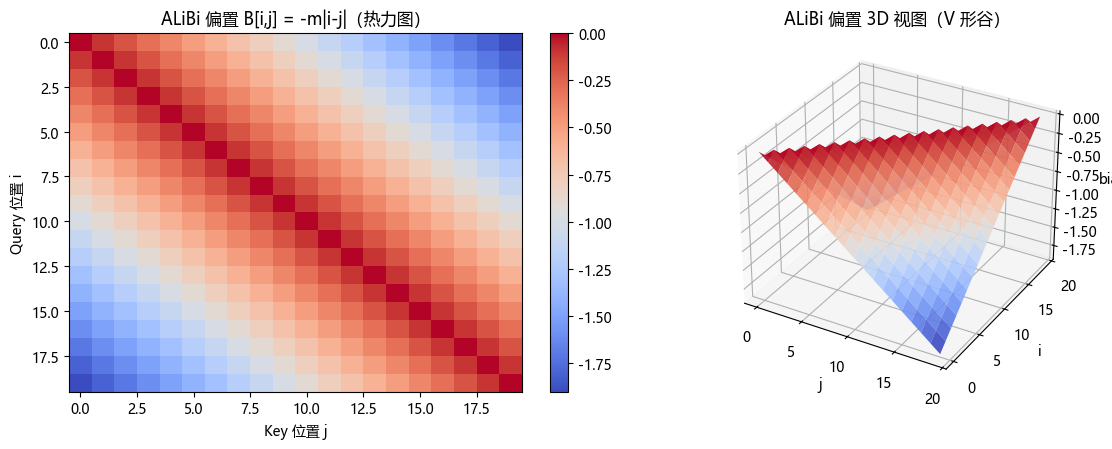

In [17]:
# 变种四：可视化 —— 偏置矩阵（热力图 + 3D 曲面，V 形谷）
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  # 3D 投影需要
fig = plt.figure(figsize=(12, 4.6))
ax1 = fig.add_subplot(1, 2, 1)                       # ① 热力图：对角线为 0，越远越负
im = ax1.imshow(bias_alibi, cmap='coolwarm', aspect='auto')
ax1.set_title('ALiBi 偏置 B[i,j] = -m|i-j|（热力图）')
ax1.set_xlabel('Key 位置 j'); ax1.set_ylabel('Query 位置 i')
fig.colorbar(im, ax=ax1)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')      # ② 3D 曲面：沿对角线是 V 形谷
X, Y = np.meshgrid(np.arange(T), np.arange(T))
ax2.plot_surface(X, Y, bias_alibi, cmap='coolwarm', alpha=0.9)
ax2.set_title('ALiBi 偏置 3D 视图（V 形谷）')
ax2.set_xlabel('j'); ax2.set_ylabel('i'); ax2.set_zlabel('bias')
plt.tight_layout()
plt.show()

## 变种五：T5 相对位置偏置（Relative Position Bias）

T5 用**相对位置 + 分桶（bucket）+ 可学习查表**：

1. 计算相对距离 $r = j - i$；
2. 把距离映射到有限的 **bucket**：近处一个距离一个桶（精细），远处多个距离共享一个桶（对数压缩，粗略）；
3. 每个 bucket 对应一个**可学习标量**，查表得到偏置 $b(i,j)$ 加进注意力分数：

$$
\text{score}(i, j) = \frac{q_i^{\top} k_j}{\sqrt{d}} \;+\; b\big(\text{bucket}(j - i)\big)
$$

分桶规则（教学用简化版，与 T5 原文精神一致）：$|r| < 16$ 时一个距离一个桶；$|r| \ge 16$ 时按对数间距压缩；负数方向对称映射到表的另一半。用很少的参数量（如 64 个标量）覆盖任意长距离，且对长距离更鲁棒。

In [18]:
# 变种五：T5 相对位置偏置 —— 手搓简化版（bucket 分桶 + 查表）
def t5_bucket_numpy(relative_pos, num_buckets=32, max_distance=128):
    """把相对距离 r=j-i 映射到桶号：|r|<16 逐距离一桶（精细）；|r|≥16 对数压缩（粗略）；负距离对称"""
    half = num_buckets // 2
    r = np.abs(relative_pos.astype(np.float64))
    ratio = np.log(np.maximum(r, 1.0) / half) / np.log(max_distance / half)   # 对数比例 [0,1)
    coarse = (half + ratio * half).astype(np.int64)                            # 远距离对数桶
    bucket = np.where(r < half, r.astype(np.int64), np.minimum(coarse, num_buckets - 1))
    bucket = np.where(relative_pos < 0, bucket + num_buckets, bucket)          # 负距离对称
    return bucket

def t5_relative_bias_numpy(T, num_buckets=32, max_distance=128, seed=0):
    """生成 T5 偏置矩阵：可学习 bias 表（64 标量）按桶号查表"""
    rng = np.random.RandomState(seed)
    bias_table = (rng.randn(num_buckets * 2).astype(np.float32) * 0.5)   # 可学习参数表
    i = np.arange(T)[:, None]; j = np.arange(T)[None, :]
    rel = j - i                                        # 相对位置 r = j - i
    bucket = t5_bucket_numpy(rel, num_buckets, max_distance)
    bias = bias_table[bucket]                          # 查表 → 偏置矩阵
    return bias, bucket, bias_table

bias_t5, bucket_t5, bias_table_np = t5_relative_bias_numpy(T)
print('桶号矩阵（前 6×6）：\n', bucket_t5[:6, :6])

桶号矩阵（前 6×6）：
 [[ 0  1  2  3  4  5]
 [33  0  1  2  3  4]
 [34 33  0  1  2  3]
 [35 34 33  0  1  2]
 [36 35 34 33  0  1]
 [37 36 35 34 33  0]]


In [19]:
# 变种五：torch 参考 —— 同一张表 + 同一桶号，验证查表逻辑一致
def t5_relative_bias_torch(bias_table_np, bucket_np):
    """torch 版本：桶号张量作为索引查 torch 表"""
    return torch.tensor(bias_table_np)[torch.tensor(bucket_np)]

bias_t5_t = t5_relative_bias_torch(bias_table_np, bucket_t5)
report('T5 偏置矩阵 numpy vs torch', float(np.abs(bias_t5 - bias_t5_t.numpy()).max()))
print('偏置表前 8 个可学习标量:', np.round(bias_table_np[:8], 3))

[T5 偏置矩阵 numpy vs torch] 最大误差 = 0.000e+00  ✓ PASS
偏置表前 8 个可学习标量: [ 0.882  0.2    0.489  1.12   0.934 -0.489  0.475 -0.076]


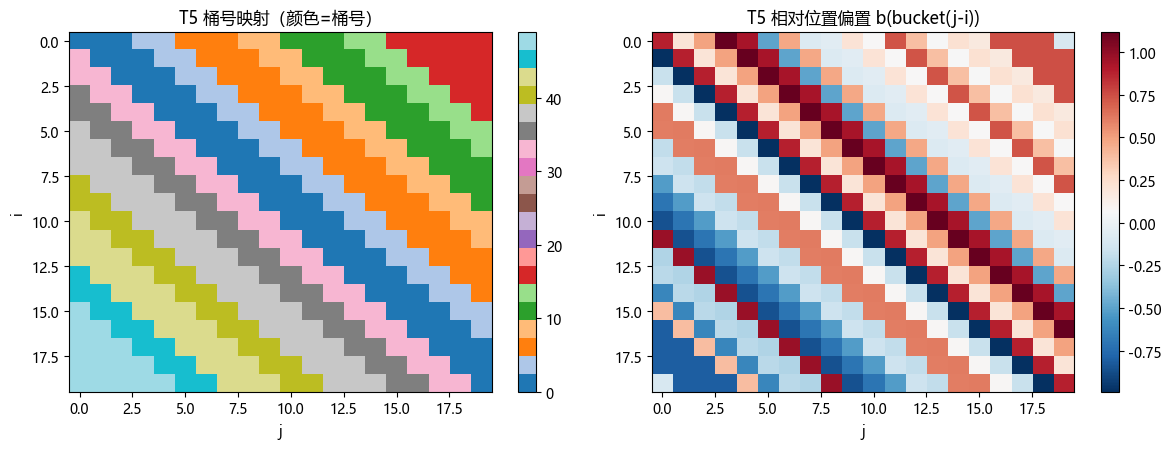

In [20]:
# 变种五：可视化 —— 桶号映射 + 偏置矩阵热力图
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
im0 = axes[0].imshow(bucket_t5, cmap='tab20', aspect='auto')   # ① 桶号：近密远疏
axes[0].set_title('T5 桶号映射（颜色=桶号）')
axes[0].set_xlabel('j'); axes[0].set_ylabel('i')
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(bias_t5, cmap='RdBu_r', aspect='auto')    # ② 可学习偏置
axes[1].set_title('T5 相对位置偏置 b(bucket(j-i))')
axes[1].set_xlabel('j'); axes[1].set_ylabel('i')
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

## 变种对比：五种"位置-位置"依赖结构

把五种变种统一画成 $T\times T$ 的矩阵图（行 = Query 位置 $i$，列 = Key 位置 $j$），直观对比它们的依赖结构：

- **① 正弦 / ② 可学习**：位置信号加在**输入**上，图中展示的是"位置编码矩阵行间点积"——靠点积间接形成位置信号，没有显式的距离结构；
- **③ RoPE**：旋转后 Q·K 分数**只依赖相对距离** → 矩阵呈 **Toeplitz 带状**（同一副对角线值相同）；
- **④ ALiBi**：分数上加**固定线性衰减**（明显的 V 形）；**⑤ T5**：分数上加**可学习分桶偏置**（近密远疏但不平滑）。

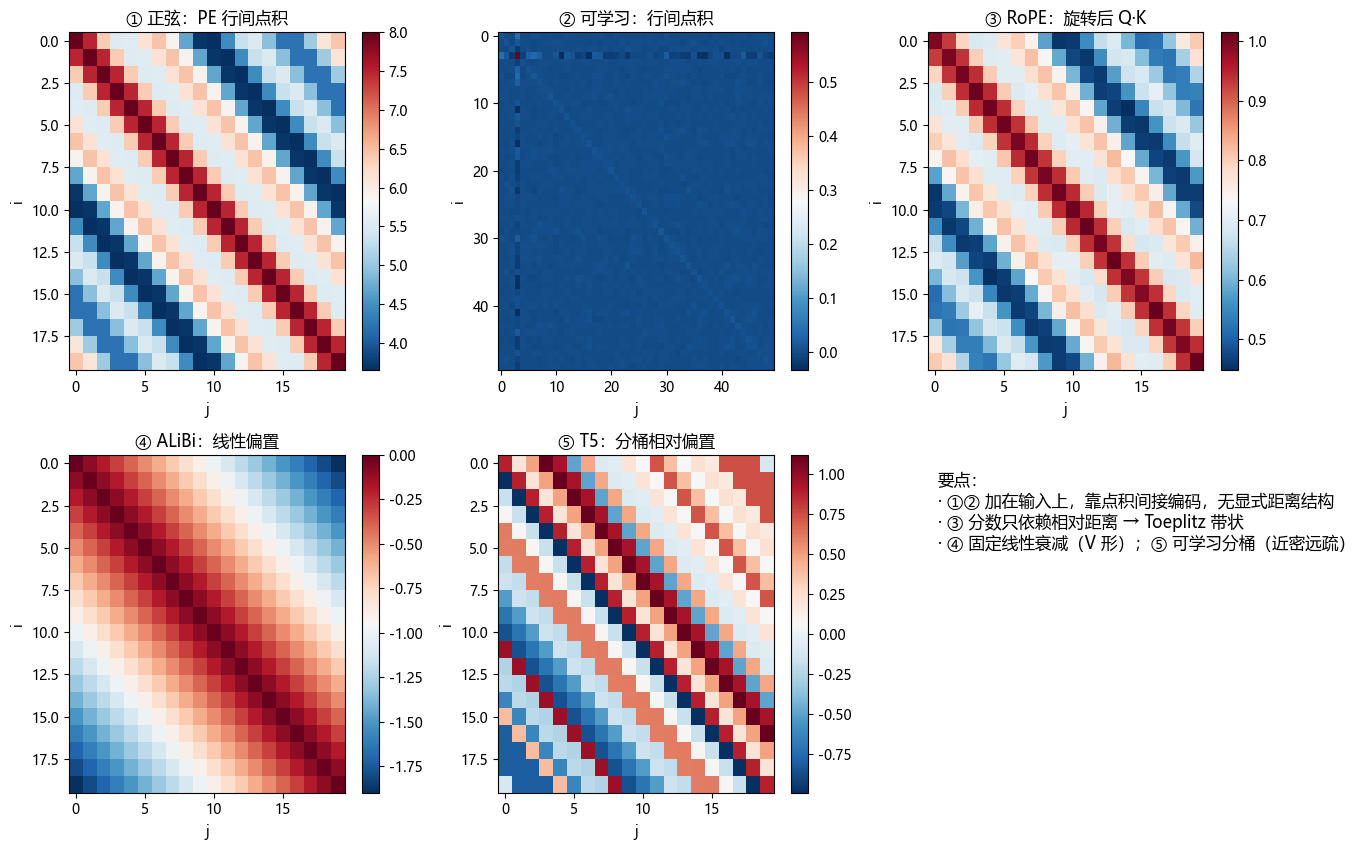

In [21]:
# 总对比：五种变种的"位置-位置"依赖结构（统一 T×T 热力图）
import matplotlib.pyplot as plt
x_same20 = (0.5 + 0.01 * np.random.RandomState(1).randn(T, D_MODEL)).astype(np.float32)  # 内容相同
freqs20 = precompute_freqs_cis_numpy(T, D_MODEL)
x_rot20 = apply_rotary_emb_numpy(x_same20, freqs20)
scores_rope = (x_rot20 @ x_rot20.T) / np.sqrt(D_MODEL)          # RoPE 旋转后 Q·K 分数
fig, axes = plt.subplots(2, 3, figsize=(14, 8.6))
axes = axes.ravel()
panels = [
    ('① 正弦：PE 行间点积', pe_np[:T] @ pe_np[:T].T),
    ('② 可学习：行间点积', P_torch @ P_torch.T),
    ('③ RoPE：旋转后 Q·K', scores_rope),
    ('④ ALiBi：线性偏置', bias_alibi),
    ('⑤ T5：分桶相对偏置', bias_t5),
]
for ax, (title, M) in zip(axes[:5], panels):                    # 前 5 面板逐张热力图
    im = ax.imshow(M, cmap='RdBu_r', aspect='auto')
    ax.set_title(title); ax.set_xlabel('j'); ax.set_ylabel('i')
    fig.colorbar(im, ax=ax)
axes[5].axis('off')                                             # 第 6 面板：文字要点
axes[5].text(0.03, 0.95, '要点：\n'
             '· ①② 加在输入上，靠点积间接编码，无显式距离结构\n'
             '· ③ 分数只依赖相对距离 → Toeplitz 带状\n'
             '· ④ 固定线性衰减（V 形）；⑤ 可学习分桶（近密远疏）',
             fontsize=12, va='top')
plt.tight_layout()
plt.show()

## 总结与选型：MiniMind 为什么用 RoPE？

**怎么选？**

| 场景 | 推荐方案 |
|---|---|
| 推理长度可能超过训练长度（强外推需求） | **RoPE / ALiBi** |
| 训练长度固定、追求实现简单 | 可学习编码（BERT 风格） |
| 编码器-解码器、跨度大、鲁棒性优先 | T5 相对偏置 |
| 教学基线、零依赖 | 正弦编码 |

**MiniMind 选择 RoPE 的理由**：

1. **显式相对位置**：旋转后 Q·K 点积只依赖相对距离，符合"越近越相关"的语言直觉；
2. **外推性好**：没有可学习编码那样的 `max_len` 硬上限，旋转角度随位置连续可算，超出训练长度仍有意义；
3. **decoder-only 高效**：因果注意力只需一次性预计算频率表，推理时与 KV-cache 配合几乎零额外开销；
4. **零新增参数**：与 ALiBi 一样不增加模型体积，还能做 YaRN 等长度外推扩展。

**minLLM 项目对应代码**（可对照阅读，`model/model_minimind.py`）：

- 第 62 行 `precompute_freqs_cis(dim, end, rope_base=1e6, rope_scaling=None)`：
  预计算角度并返回 `freqs_cos, freqs_sin`（cos 沿最后一维复制成两份，配合 `rotate_half` 技巧）；
  注意 MiniMind 的 `rope_base=1e6`（本 notebook 用 10000 便于教学，规律相同）；
- 第 80 行 `apply_rotary_pos_emb(q, k, cos, sin, unsqueeze_dim=1)`：
  `rotate_half(x) = cat([-x[d/2:], x[:d/2]])`，然后 `q·cos + rotate_half(q)·sin` ——
  **与本节"复数乘法"实现完全等价**（把旋转矩阵写成对两半维度的交叉混合）；
- 调用位置：`Attention.forward()` 中取出 `q_proj/k_proj` 结果后调用，得到带位置信息的 $q^{(rope)}, k^{(rope)}$ 再算注意力。

**一句话总结**：位置编码的进化 = 从"人工设计固定信号"（正弦）→"数据驱动查表"（可学习）→
"让点积自动携带相对位置"（RoPE）→"直接修改注意力分数"（ALiBi / T5）。
MiniMind 站在 decoder-only + 长上下文的一侧，选择了兼具**相对性、外推性与零参数**的 RoPE。